## 📦 Import Libraries

In [1]:
# ===============================
# ENV SETUP (WAJIB PALING ATAS)
# ===============================
import os
# Hindari TensorFlow mencari CUDA (tidak tersedia di macOS)
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

# ===============================
# Data manipulation
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# TensorFlow
# ===============================
import tensorflow as tf

# ===============================
# Transformers (HuggingFace)
# ===============================
from transformers import (
    DistilBertTokenizer,
    TFDistilBertForSequenceClassification,
    create_optimizer
)

# ===============================
# Scikit-learn
# ===============================
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score
)

# ===============================
# Utilities
# ===============================
import pickle
import json
import warnings
import platform
warnings.filterwarnings('ignore')

# ===============================
# Reproducibility
# ===============================
np.random.seed(42)
tf.random.set_seed(42)

# ===============================
# System Info
# ===============================
print("🍎 System Info")
print(f"OS      : {platform.system()}")
print(f"Machine : {platform.machine()}")

if platform.system() == "Darwin" and platform.machine() == "arm64":
    print("✅ Apple Silicon detected (M-series)")
    print("🚀 TensorFlow will use Metal backend automatically (if available)")
else:
    print("ℹ️ Non Apple-Silicon environment")

# ===============================
# TensorFlow Info
# ===============================
print("\n✅ Libraries imported successfully!")
print(f"📌 TensorFlow version: {tf.__version__}")

devices = tf.config.list_physical_devices()
print("🔧 Available devices:")
for d in devices:
    print(f"   - {d.device_type}")


/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🍎 System Info
OS      : Darwin
Machine : arm64
✅ Apple Silicon detected (M-series)
🚀 TensorFlow will use Metal backend automatically (if available)

✅ Libraries imported successfully!
📌 TensorFlow version: 2.13.0
🔧 Available devices:
   - CPU


## 📁 Load Preprocessed Data

In [2]:
# Load data
train_df = pd.read_csv('../data/processed/train.csv')
val_df = pd.read_csv('../data/processed/val.csv')
test_df = pd.read_csv('../data/processed/test.csv')

print("📊 Data Loaded:")
print(f"   Training:   {len(train_df):,} samples")
print(f"   Validation: {len(val_df):,} samples")
print(f"   Test:       {len(test_df):,} samples")

📊 Data Loaded:
   Training:   36,861 samples
   Validation: 7,899 samples
   Test:       7,899 samples


In [3]:
# Load label encoder
with open('../models/label_encoder.pkl', 'rb') as f:
    label_encoder = pickle.load(f)

# Load metadata
with open('../data/processed/metadata.pkl', 'rb') as f:
    metadata = pickle.load(f)

num_classes = metadata['num_classes']

print(f"\n🏷️ Label Info:")
print(f"   Number of classes: {num_classes}")
print(f"   Classes: {metadata['classes']}")


🏷️ Label Info:
   Number of classes: 7
   Classes: ['Anxiety', 'Bipolar', 'Depression', 'Normal', 'Personality disorder', 'Stress', 'Suicidal']


In [4]:
# Untuk DistilBERT, gunakan cleaned_text (dengan stopwords)
X_train = train_df['cleaned_text'].fillna('').astype(str).values
X_val = val_df['cleaned_text'].fillna('').astype(str).values
X_test = test_df['cleaned_text'].fillna('').astype(str).values

y_train = train_df['label_encoded'].values
y_val = val_df['label_encoded'].values
y_test = test_df['label_encoded'].values

print("✅ Data prepared for DistilBERT training")
print(f"   Train samples with empty text: {sum(len(x.strip()) == 0 for x in X_train)}")
print(f"   Val samples with empty text: {sum(len(x.strip()) == 0 for x in X_val)}")
print(f"   Test samples with empty text: {sum(len(x.strip()) == 0 for x in X_test)}")

✅ Data prepared for DistilBERT training
   Train samples with empty text: 0
   Val samples with empty text: 0
   Test samples with empty text: 0


## 🔤 DistilBERT Tokenization

In [5]:
# Load DistilBERT Tokenizer
print("📥 Loading DistilBERT tokenizer...")
distilbert_tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
print("✅ DistilBERT tokenizer loaded!")

# Hyperparameters
MAX_LEN_DISTILBERT = 128

print(f"\n⚙️ Hyperparameters:")
print(f"   MAX_LEN: {MAX_LEN_DISTILBERT}")

📥 Loading DistilBERT tokenizer...
✅ DistilBERT tokenizer loaded!

⚙️ Hyperparameters:
   MAX_LEN: 128


In [6]:
def encode_texts(texts, tokenizer, max_length):
    """
    Encode texts menggunakan DistilBERT tokenizer
    Returns: input_ids dan attention_masks
    """
    input_ids = []
    attention_masks = []
    
    for text in texts:
        encoded = tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='tf'
        )
        input_ids.append(encoded['input_ids'])
        attention_masks.append(encoded['attention_mask'])
    
    return tf.concat(input_ids, axis=0), tf.concat(attention_masks, axis=0)

print("✅ Encoding function ready")

✅ Encoding function ready


In [7]:
# Encode datasets
print("🔤 Encoding texts for DistilBERT...")
print("⏰ This may take a few minutes...\n")

print("   Encoding training set...")
X_train_ids, X_train_masks = encode_texts(X_train.tolist(), distilbert_tokenizer, MAX_LEN_DISTILBERT)

print("   Encoding validation set...")
X_val_ids, X_val_masks = encode_texts(X_val.tolist(), distilbert_tokenizer, MAX_LEN_DISTILBERT)

print("   Encoding test set...")
X_test_ids, X_test_masks = encode_texts(X_test.tolist(), distilbert_tokenizer, MAX_LEN_DISTILBERT)

print("\n✅ Encoding complete!")
print(f"   Train IDs shape: {X_train_ids.shape}")
print(f"   Val IDs shape: {X_val_ids.shape}")
print(f"   Test IDs shape: {X_test_ids.shape}")

🔤 Encoding texts for DistilBERT...
⏰ This may take a few minutes...

   Encoding training set...
   Encoding validation set...
   Encoding test set...

✅ Encoding complete!
   Train IDs shape: (36861, 128)
   Val IDs shape: (7899, 128)
   Test IDs shape: (7899, 128)


## 🏗️ Load DistilBERT Model

In [8]:
# Load pretrained DistilBERT
print("📥 Loading DistilBERT model from Hugging Face...")
print("⏰ This may take a few minutes for first time...\n")

# Fix: Use use_safetensors=False to avoid safetensors iteration bug
distilbert_model = TFDistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=num_classes,
    use_safetensors=False  # Force loading from h5/pickle format instead of safetensors
)

print("✅ DistilBERT model loaded!")
print(f"   Model: distilbert-base-uncased")
print(f"   Parameters: ~66M (40% smaller than BERT)")
print(f"   Speed: 60% faster than BERT")
print(f"   Output classes: {num_classes}")

📥 Loading DistilBERT model from Hugging Face...
⏰ This may take a few minutes for first time...



TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some layers from the model checkpoint at distilbert-base-uncased were not used when initializing TFDistilBertForSequenceClassification: ['activation_13', 'vocab_layer_norm', 'vocab_projector', 'vocab_transform']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFDistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-

✅ DistilBERT model loaded!
   Model: distilbert-base-uncased
   Parameters: ~66M (40% smaller than BERT)
   Speed: 60% faster than BERT
   Output classes: 7


## ⚙️ Compile Model

In [9]:
# Hyperparameters for training
EPOCHS = 3
BATCH_SIZE = 16
LEARNING_RATE = 2e-5

# Calculate total training steps
num_train_steps = (len(X_train) // BATCH_SIZE) * EPOCHS
num_warmup_steps = int(0.1 * num_train_steps)

print(f"⚙️ Training Configuration:")
print(f"   Epochs: {EPOCHS}")
print(f"   Batch Size: {BATCH_SIZE}")
print(f"   Learning Rate: {LEARNING_RATE}")
print(f"   Total Training Steps: {num_train_steps:,}")
print(f"   Warmup Steps: {num_warmup_steps:,}")

⚙️ Training Configuration:
   Epochs: 3
   Batch Size: 16
   Learning Rate: 2e-05
   Total Training Steps: 6,909
   Warmup Steps: 690


In [10]:
# Create optimizer
optimizer, lr_schedule = create_optimizer(
    init_lr=LEARNING_RATE,
    num_train_steps=num_train_steps,
    num_warmup_steps=num_warmup_steps
)

# Compile model
distilbert_model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

print("✅ Model compiled!")

✅ Model compiled!


## 🏋️ Fine-tuning DistilBERT

In [11]:
# Callbacks
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True,
    verbose=1
)

print("✅ Callbacks configured")

✅ Callbacks configured


In [12]:
# Training
print("🏋️ Fine-tuning DistilBERT Model...\n")
print("💡 DistilBERT lebih cepat dari BERT!")
print("   ⏰ Estimasi waktu: 30-90 menit (tergantung GPU/CPU)\n")

history_distilbert = distilbert_model.fit(
    {'input_ids': X_train_ids, 'attention_mask': X_train_masks},
    y_train,
    validation_data=(
        {'input_ids': X_val_ids, 'attention_mask': X_val_masks},
        y_val
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

print("\n✅ DistilBERT Fine-tuning Complete!")

🏋️ Fine-tuning DistilBERT Model...

💡 DistilBERT lebih cepat dari BERT!
   ⏰ Estimasi waktu: 30-90 menit (tergantung GPU/CPU)

Epoch 1/3
2304/2304 [==============================] - 2375s 1s/step - loss: 0.7841 - accuracy: 0.7010 - val_loss: 0.4903 - val_accuracy: 0.8106
Epoch 2/3
2304/2304 [==============================] - 2408s 1s/step - loss: 0.4424 - accuracy: 0.8254 - val_loss: 0.4546 - val_accuracy: 0.8204
Epoch 3/3
2304/2304 [==============================] - 2404s 1s/step - loss: 0.3305 - accuracy: 0.8713 - val_loss: 0.4508 - val_accuracy: 0.8240

✅ DistilBERT Fine-tuning Complete!


## 💾 Save DistilBERT Model

In [13]:
# Save model
print("💾 Saving DistilBERT model...")
distilbert_model.save_pretrained('../models/distilbert_model')

print("✅ DistilBERT model saved: models/distilbert_model/")

💾 Saving DistilBERT model...
✅ DistilBERT model saved: models/distilbert_model/


## 📊 Visualisasi Training History

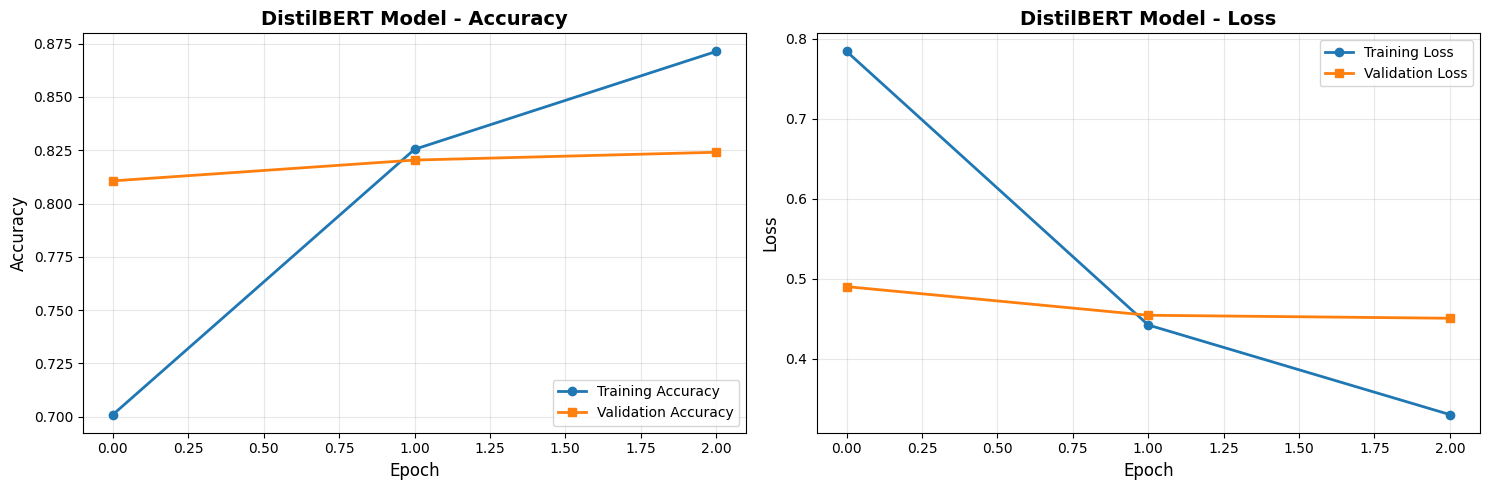

✅ Training history plot saved: results/04_distilbert_training_history.png


In [14]:
# Plot Training History
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy
axes[0].plot(history_distilbert.history['accuracy'], label='Training Accuracy', linewidth=2, marker='o')
axes[0].plot(history_distilbert.history['val_accuracy'], label='Validation Accuracy', linewidth=2, marker='s')
axes[0].set_title('DistilBERT Model - Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(history_distilbert.history['loss'], label='Training Loss', linewidth=2, marker='o')
axes[1].plot(history_distilbert.history['val_loss'], label='Validation Loss', linewidth=2, marker='s')
axes[1].set_title('DistilBERT Model - Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend(loc='upper right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../results/04_distilbert_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Training history plot saved: results/04_distilbert_training_history.png")

## 🎯 Evaluasi Model pada Test Set

In [15]:
# Predict pada test set
print("🔮 Predicting on test set...")
y_pred_logits = distilbert_model.predict(
    {'input_ids': X_test_ids, 'attention_mask': X_test_masks},
    verbose=0
)

y_pred = np.argmax(y_pred_logits.logits, axis=1)

print("✅ Prediction complete!")

🔮 Predicting on test set...
✅ Prediction complete!


## 📋 Classification Report

In [16]:
# Classification Report
print("="*80)
print("📋 DISTILBERT MODEL - CLASSIFICATION REPORT")
print("="*80)
print()
class_report = classification_report(
    y_test, 
    y_pred, 
    target_names=label_encoder.classes_,
    digits=4
)
print(class_report)

# Save classification report
with open('../results/04_distilbert_classification_report.txt', 'w') as f:
    f.write(class_report)

print("💾 Classification report saved: results/04_distilbert_classification_report.txt")

📋 DISTILBERT MODEL - CLASSIFICATION REPORT

                      precision    recall  f1-score   support

             Anxiety     0.7927    0.8698    0.8295       576
             Bipolar     0.8614    0.7602    0.8076       417
          Depression     0.7694    0.7298    0.7491      2309
              Normal     0.9414    0.9510    0.9462      2451
Personality disorder     0.6813    0.6770    0.6791       161
              Stress     0.6699    0.7113    0.6900       388
            Suicidal     0.6942    0.7220    0.7078      1597

            accuracy                         0.8067      7899
           macro avg     0.7729    0.7744    0.7728      7899
        weighted avg     0.8074    0.8067    0.8065      7899

💾 Classification report saved: results/04_distilbert_classification_report.txt


In [17]:
# Calculate accuracy
distilbert_accuracy = accuracy_score(y_test, y_pred)

print("="*80)
print(f"🎯 DISTILBERT MODEL TEST ACCURACY: {distilbert_accuracy:.4f} ({distilbert_accuracy*100:.2f}%)")
print("="*80)

🎯 DISTILBERT MODEL TEST ACCURACY: 0.8067 (80.67%)


## 🔲 Confusion Matrix

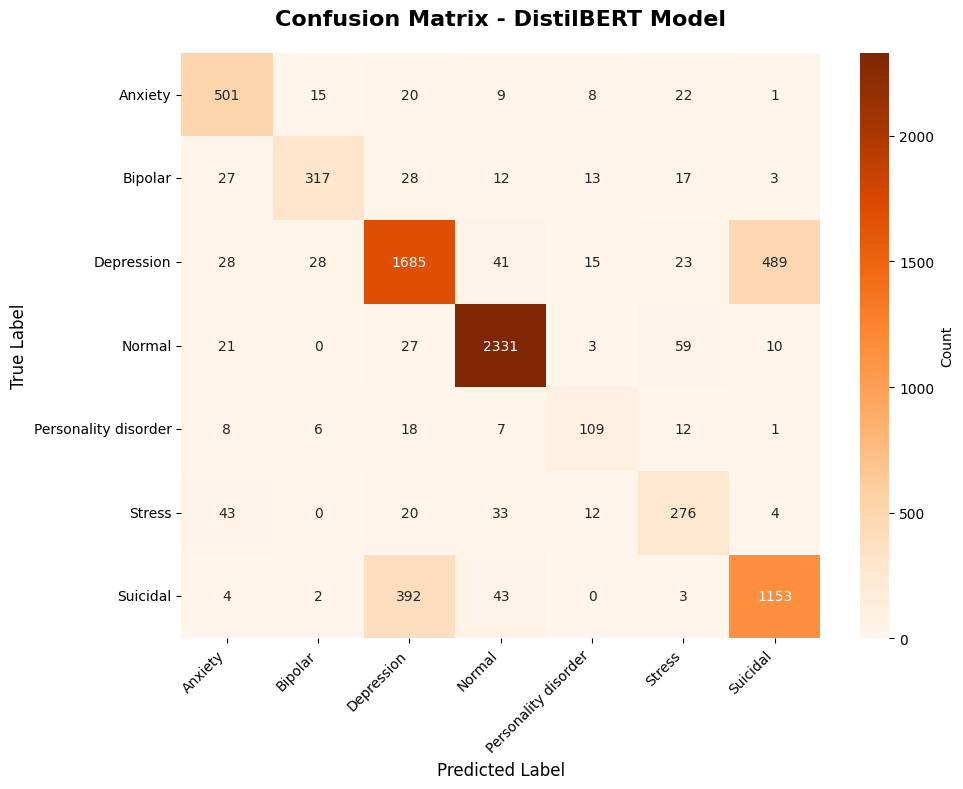

✅ Confusion matrix saved: results/04_distilbert_confusion_matrix.png


In [18]:
# Confusion Matrix
cm_distilbert = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_distilbert, 
    annot=True, 
    fmt='d', 
    cmap='Oranges',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    cbar_kws={'label': 'Count'}
)
plt.title('Confusion Matrix - DistilBERT Model', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('../results/04_distilbert_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Confusion matrix saved: results/04_distilbert_confusion_matrix.png")

## 💾 Simpan Hasil Evaluasi

In [19]:
# Simpan hasil evaluasi
distilbert_results = {
    'model_name': 'DistilBERT (Pretrained)',
    'accuracy': float(distilbert_accuracy),
    'test_size': len(y_test),
    'num_classes': num_classes,
    'hyperparameters': {
        'max_len': MAX_LEN_DISTILBERT,
        'epochs': EPOCHS,
        'batch_size': BATCH_SIZE,
        'learning_rate': LEARNING_RATE,
        'model_name': 'distilbert-base-uncased'
    },
    'training_history': {
        'epochs_trained': len(history_distilbert.history['accuracy']),
        'final_train_accuracy': float(history_distilbert.history['accuracy'][-1]),
        'final_val_accuracy': float(history_distilbert.history['val_accuracy'][-1]),
        'final_train_loss': float(history_distilbert.history['loss'][-1]),
        'final_val_loss': float(history_distilbert.history['val_loss'][-1]),
        'best_val_accuracy': float(max(history_distilbert.history['val_accuracy'])),
        'best_val_loss': float(min(history_distilbert.history['val_loss']))
    }
}

# Save to JSON
with open('../results/04_distilbert_results.json', 'w') as f:
    json.dump(distilbert_results, f, indent=4)

print("✅ Results saved: results/04_distilbert_results.json")

✅ Results saved: results/04_distilbert_results.json


In [20]:
# Simpan history
history_dict = {
    'accuracy': [float(x) for x in history_distilbert.history['accuracy']],
    'val_accuracy': [float(x) for x in history_distilbert.history['val_accuracy']],
    'loss': [float(x) for x in history_distilbert.history['loss']],
    'val_loss': [float(x) for x in history_distilbert.history['val_loss']]
}

with open('../results/04_distilbert_history.json', 'w') as f:
    json.dump(history_dict, f, indent=4)

print("✅ Training history saved: results/04_distilbert_history.json")

✅ Training history saved: results/04_distilbert_history.json


## 📊 Summary

In [21]:
print("\n" + "="*80)
print("📊 DISTILBERT MODEL TRAINING SUMMARY")
print("="*80)

print(f"\n🏗️ Model:")
print(f"   - Type: DistilBERT (Pretrained)")
print(f"   - Base Model: distilbert-base-uncased")
print(f"   - Parameters: ~66M (40% smaller than BERT)")
print(f"   - Speed: 60% faster than BERT")
print(f"   - Max Sequence Length: {MAX_LEN_DISTILBERT}")

print(f"\n🏋️ Training:")
print(f"   - Epochs Trained: {len(history_distilbert.history['accuracy'])}")
print(f"   - Batch Size: {BATCH_SIZE}")
print(f"   - Learning Rate: {LEARNING_RATE}")
print(f"   - Final Training Accuracy: {history_distilbert.history['accuracy'][-1]:.4f}")
print(f"   - Final Validation Accuracy: {history_distilbert.history['val_accuracy'][-1]:.4f}")

print(f"\n🎯 Test Results:")
print(f"   - Test Accuracy: {distilbert_accuracy:.4f} ({distilbert_accuracy*100:.2f}%)")
print(f"   - Test Samples: {len(y_test):,}")

print(f"\n💾 Files Saved:")
print(f"   ✓ models/distilbert_model/")
print(f"   ✓ results/04_distilbert_training_history.png")
print(f"   ✓ results/04_distilbert_confusion_matrix.png")
print(f"   ✓ results/04_distilbert_classification_report.txt")
print(f"   ✓ results/04_distilbert_results.json")
print(f"   ✓ results/04_distilbert_history.json")

print(f"\n🎯 Next Step: 05_model_comparison.ipynb ⭐")
print("="*80)


📊 DISTILBERT MODEL TRAINING SUMMARY

🏗️ Model:
   - Type: DistilBERT (Pretrained)
   - Base Model: distilbert-base-uncased
   - Parameters: ~66M (40% smaller than BERT)
   - Speed: 60% faster than BERT
   - Max Sequence Length: 128

🏋️ Training:
   - Epochs Trained: 3
   - Batch Size: 16
   - Learning Rate: 2e-05
   - Final Training Accuracy: 0.8713
   - Final Validation Accuracy: 0.8240

🎯 Test Results:
   - Test Accuracy: 0.8067 (80.67%)
   - Test Samples: 7,899

💾 Files Saved:
   ✓ models/distilbert_model/
   ✓ results/04_distilbert_training_history.png
   ✓ results/04_distilbert_confusion_matrix.png
   ✓ results/04_distilbert_classification_report.txt
   ✓ results/04_distilbert_results.json
   ✓ results/04_distilbert_history.json

🎯 Next Step: 05_model_comparison.ipynb ⭐
